In [4]:
import pandas as pd


df = pd.read_csv("disney_content_analytics.csv")


df.head()

,User_ID,Content_Name,Genre,Watch_Time,Completion_%,Rating,Region
0,1,Moana,Marvel,189,72,4.6,India
1,2,Rogue One,Star Wars,271,70,3.8,Singapore
2,3,The Lion King,Pixar,276,90,3.5,India
3,4,Moana,NatGeo,193,65,3.5,India
4,5,Coco,Disney,169,36,2.3,India


In [2]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 4.623900000095367 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User_ID       190 non-null    int64  
 1   Content_Name  190 non-null    str    
 2   Genre         190 non-null    str    
 3   Watch_Time    190 non-null    int64  
 4   Completion_%  190 non-null    int64  
 5   Rating        190 non-null    float64
 6   Region        190 non-null    str    
dtypes: float64(1), int64(3), str(3)
memory usage: 8.2 KB


User_ID         0
Content_Name    0
Genre           0
Watch_Time      0
Completion_%    0
Rating          0
Region          0
dtype: int64

In [6]:
print("Total Records:", len(df))
print("Average Watch Time:", round(df['Watch_Time'].mean(),1))
print("Average Completion %:", round(df['Completion_%'].mean(),1))
print("Average Rating:", round(df['Rating'].mean(),1))

Total Records: 190
Average Watch Time: 154.0
Average Completion %: 70.3
Average Rating: 4.0


In [7]:
top_watch = df.groupby("Content_Name")['Watch_Time'].mean().sort_values(ascending=False)
top_completion = df.groupby("Content_Name")['Completion_%'].mean().sort_values(ascending=False)

print("Top content by Watch Time:\n", top_watch.head(10))
print("\nTop content by Completion %:\n", top_completion.head(10))

Top content by Watch Time:
 Content_Name
Coco                       191.833333
Incredibles 2              176.333333
Black Panther              169.187500
Star Wars: A New Hope      161.250000
Rogue One                  157.705882
Guardians of the Galaxy    154.133333
Moana                      152.619048
The Lion King              150.000000
Avengers: Endgame          147.222222
Toy Story 4                140.923077
Name: Watch_Time, dtype: float64

Top content by Completion %:
 Content_Name
The Lion King                  77.285714
Moana                          75.428571
Guardians of the Galaxy        73.333333
Star Wars: A New Hope          73.166667
Rogue One                      72.470588
Frozen II                      69.666667
Black Panther                  68.750000
Incredibles 2                  67.611111
National Geographic: Oceans    67.500000
Avengers: Endgame              65.555556
Name: Completion_%, dtype: float64


In [8]:
genre_perf = df.groupby("Genre")['Watch_Time'].mean().sort_values(ascending=False)
print("Genre Performance by Watch Time:\n", genre_perf)

Genre Performance by Watch Time:
 Genre
Pixar        160.194444
Marvel       156.923077
NatGeo       156.388889
Disney       155.477273
Star Wars    140.028571
Name: Watch_Time, dtype: float64


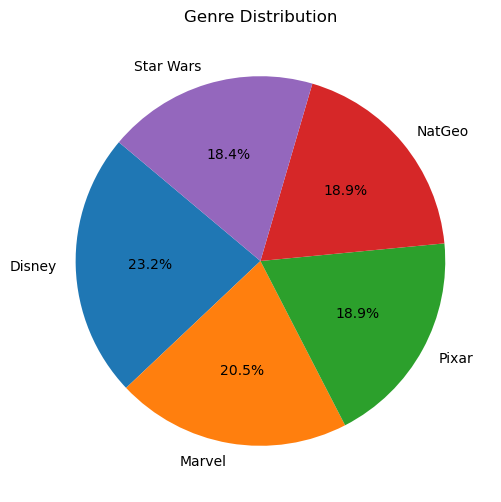

In [9]:
import matplotlib.pyplot as plt

df['Genre'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), startangle=140)
plt.title("Genre Distribution")
plt.ylabel("")
plt.show()

In [10]:
region_pref = df.groupby("Region")['Watch_Time'].mean().sort_values(ascending=False)
print("Average Watch Time by Region:\n", region_pref)

Average Watch Time by Region:
 Region
Singapore    168.333333
Indonesia    157.638889
Thailand     153.902439
India        148.179487
Malaysia     131.346154
Name: Watch_Time, dtype: float64


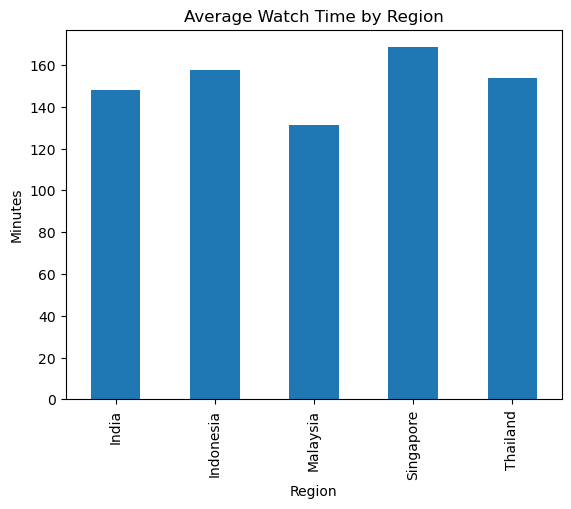

In [11]:
df.groupby("Region")['Watch_Time'].mean().plot(kind='bar')
plt.title("Average Watch Time by Region")
plt.ylabel("Minutes")
plt.show()

In [12]:

df['Recommended_Genre'] = df['Genre']


df['Recommended_Content'] = df['Content_Name']

df[['User_ID','Content_Name','Genre','Recommended_Content','Recommended_Genre']].head(10)

,User_ID,Content_Name,Genre,Recommended_Content,Recommended_Genre
0,1,Moana,Marvel,Moana,Marvel
1,2,Rogue One,Star Wars,Rogue One,Star Wars
2,3,The Lion King,Pixar,The Lion King,Pixar
3,4,Moana,NatGeo,Moana,NatGeo
4,5,Coco,Disney,Coco,Disney
5,6,Avengers: Endgame,Marvel,Avengers: Endgame,Marvel
6,7,The Lion King,NatGeo,The Lion King,NatGeo
7,8,Avengers: Endgame,NatGeo,Avengers: Endgame,NatGeo
8,9,Rogue One,NatGeo,Rogue One,NatGeo
9,10,The Lion King,Disney,The Lion King,Disney


In [13]:
df['Engagement_Score'] = (
    df['Watch_Time'] * 0.4 +
    df['Completion_%'] * 0.4 +
    df['Rating'] * 20 * 0.2
)

df[['Content_Name', 'Engagement_Score']].head()

,Content_Name,Engagement_Score
0,Moana,122.8
1,Rogue One,151.6
2,The Lion King,160.4
3,Moana,117.2
4,Coco,91.2


In [14]:
df['Recommendation_Strength'] = (
    df['Rating'] * 0.5 +
    df['Completion_%'] * 0.3 +
    df['Watch_Time'] * 0.2
)

In [15]:
df['Binge_Watch'] = df['Watch_Time'] > 180

In [ ]:
content_popularity = df.groupby('Content_Name')['User_ID'].transform('count')

df['Popularity_Score'] = content_popularity